Saving image.png to image.png
Original Image


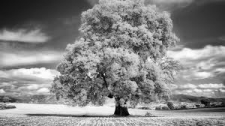

Gradient Mask


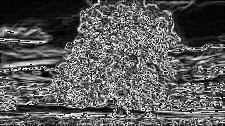

Sharpened Image (Gradient Masking)


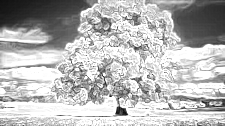

In [1]:
# ==========================================
# Image Sharpening using Gradient Masking
# Google Colab - Single Cell
# ==========================================

import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# Step 1: Upload Image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Step 2: Read Image
image = cv2.imread(image_path)

# Step 3: Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray_float = gray.astype(np.float32)

# Step 4: Compute Gradient using Sobel
grad_x = cv2.Sobel(gray_float, cv2.CV_32F, 1, 0, ksize=3)
grad_y = cv2.Sobel(gray_float, cv2.CV_32F, 0, 1, ksize=3)

# Step 5: Compute Gradient Magnitude
gradient = cv2.magnitude(grad_x, grad_y)

# Step 6: Add Gradient Mask to Original Image
k = 0.5   # sharpening strength
sharpened = gray_float + k * gradient

# Step 7: Convert back to uint8
sharpened = np.clip(sharpened, 0, 255)
sharpened = sharpened.astype(np.uint8)

# Step 8: Show Results
print("Original Image")
cv2_imshow(gray)

print("Gradient Mask")
cv2_imshow(gradient.astype(np.uint8))

print("Sharpened Image (Gradient Masking)")
cv2_imshow(sharpened)
